Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

## **Question 1:**

(8 points)

Numerically estimate f′(x) for f(x) = sin(x) at x = 2π/5, using

(a) Forward difference: f′
n ≈ (fn+1 − fn)/h

(b) Backward difference: f′
n ≈ (fn − fn−1)/h

(c) Central difference: f′
n ≈ (fn+1 − fn−1)/(2h)

(d) Five-point approximation: f′
n ≈ (fn−2 − 8fn−1 + 8fn+1 − fn+2)/(12h)

*for h = [0.5,0.2,0.1,0.05,0.02,0.01,0.005,0.002,0.001,0.0005,0.0002,0.0001].*

(a) (3 points) Create a table to record the estimate derivatives using different methods for each h.

(b) (3 points) Plot the differences between exact values and the estimated values (the error).

(c) (2 points) Fit the log of the error versus the log of h and compare the efficiencies of the methods



Defining functions for differentiaition

In [3]:
# Forward Difference
def forward_diff(f, xn, h):
  return (f(xn+h) - f(xn))/h

# Backward Difference
def backward_diff(f, xn, h):
  return (f(xn) - f(xn-h))/h

# Central Difference
def central_diff(f, xn, h):
  return (f(xn+h) - f(xn-h))/(2*h)

# Five Point Approximation
def five_point_approx(f, xn, h):
  return (f(xn-2*h) - 8*f(xn-h) + 8*f(xn+h) - f(xn+2*h))/(12*h)


Defining variables and f(x)

In [4]:
# List of all h values
hs =  [0.5,0.2,0.1,0.05,0.02,0.01,0.005,0.002,0.001,0.0005,0.0002,0.0001]

# List of all methods
methods = [forward_diff, backward_diff, central_diff, five_point_approx]

# Exact value of derivative of sin x
x = 2*np.pi/5
exact = np.cos(x)

# Defining f(x)
def f1(x):
  return np.sin(x)

**Part (a):**

Printing Table of different derivatives and recording errors

In [5]:
# Creating array to store errors of various methods
errors_diff = np.zeros((len(hs), len(methods)))
print("h values  Forward   Backward  Central  Five-point  Exact")

for row in range(len(hs)):
  h = hs[row]
  print("%0.5f" %h, end = " "*3)

  for col in range(len(methods)):
    value = methods[col](f1, x, h)
    print("%0.5f" %value, end = " "*3)
    errors_diff[row, col] = abs(value - exact)   # Errors are stored in the same format in which the table is printed

  print("%0.5f" %exact)

h values  Forward   Backward  Central  Five-point  Exact
0.50000   0.06345   0.52915   0.29630   0.30839   0.30902
0.20000   0.21217   0.40175   0.30696   0.30900   0.30902
0.10000   0.26099   0.35602   0.30850   0.30902   0.30902
0.05000   0.28512   0.33266   0.30889   0.30902   0.30902
0.02000   0.29949   0.31851   0.30900   0.30902   0.30902
0.01000   0.30426   0.31377   0.30901   0.30902   0.30902
0.00500   0.30664   0.31139   0.30902   0.30902   0.30902
0.00200   0.30807   0.30997   0.30902   0.30902   0.30902
0.00100   0.30854   0.30949   0.30902   0.30902   0.30902
0.00050   0.30878   0.30925   0.30902   0.30902   0.30902
0.00020   0.30892   0.30911   0.30902   0.30902   0.30902
0.00010   0.30897   0.30906   0.30902   0.30902   0.30902


**Part (b):**

Plotting the errors v/s h-values

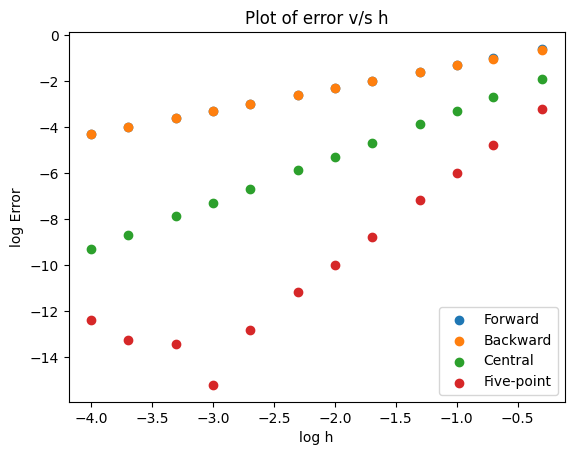

In [6]:
labels_diff = ["Forward", "Backward", "Central", "Five-point"]

for i in range(len(methods)):
  plt.scatter(np.log10(hs), np.log10(errors_diff[:, i]), label = labels_diff[i])

plt.xlabel("log h")
plt.ylabel("log Error")
plt.title("Plot of error v/s h")
plt.legend()
plt.show()

**Part (c):**

Fit of log of error v/s log of h

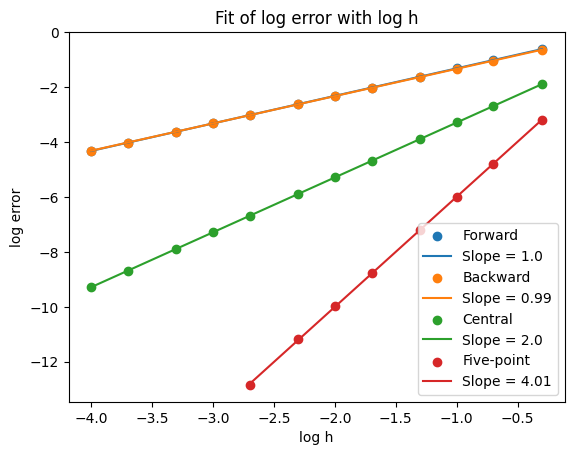

'\nForward and Backward:\nAs can be seen from the plot, the slope is 1. This means log error = log h => Error is directly proportional to h\n\nCentral:\nSlope = 2 => log error = 2*log h => Error proportional to h^2 - better approximation method\n\nFive-point:\nSlope = 4 => log error = 4*log h => Error proportional to h^4 - best approximation method among all\n'

In [7]:
# Equation of a straight line
def eqn_of_line(x, m, c):
  return m*x + c

# Fitting the error points with a straight line
for i in range(len(methods)):
  # Arrays for fitting
  xs = np.log10(hs)
  ys = np.log10(errors_diff[:, i])

  # Five-point approximation has some noise (machine epsilon) for very small h values; excluding small h values in order to to record correct behaviour
  if i == 3:
    xs = xs[:8]
    ys = ys[:8]

  # Determining fit parameters
  popt, pcov = curve_fit(eqn_of_line, xs, ys)
  slope, intercept = popt

  # Plotting
  plt.scatter(xs, ys, label = labels_diff[i])
  plt.plot(xs, eqn_of_line(xs, slope, intercept), label = f"Slope = {round(slope, 2)}")

# Labelling the plot
plt.xlabel("log h")
plt.ylabel("log error")
plt.title("Fit of log error with log h")
plt.legend()
plt.show()

'''
Forward and Backward:
As can be seen from the plot, the slope is 1. This means log error = log h => Error is directly proportional to h

Central:
Slope = 2 => log error = 2*log h => Error proportional to h^2 - better approximation method

Five-point:
Slope = 4 => log error = 4*log h => Error proportional to h^4 - best approximation method among all
'''

## **Question 2:**

Numerically estimate int(0 to 1) f(x)dx for f(x) = e^x, using the following methods:

(a) Linear (Trapezoidal):

(b) Quadratic (Simpson’s 1/3
rule):

(c) Cubic (Simpson’s 3/8
rule):

(d) Quartic (Boole’s rule):

(a) (4 points) Consider the interval [0,1). Choose m from [4,8,16,32,64]. For trapezoidal and
Simpson’s 1/3, N = 2m + 1. For Simpson’s 3/8, N = 3m + 1 and for Boole’s method N =
4m +1. Create a table to record the estimate integral using different methods for each h =
(1.0 − 0.0)/(N − 1) value.

(b) (2 points) Plot the differences between exact values and the estimated values (the error).

(c) (2 points) Fit the log of the error versus the log of h and compare the efficiencies of the methods.

Defining functions for integration

In [8]:
# Trapezoidal Method
def trapezoidal(f, m: int, lower: float = 0, upper: float = 1):
  N = 2*m+1
  h = (upper-lower)/(N-1)
  hs = np.linspace(lower, upper, N)
  fs = np.array(f(hs))

  s = (h/2)*(fs[0] + fs[-1] + 2*sum(fs[1:-1]))
  return (s, h)

# Simpson's 1/3 Method
def simpson_13(f, m: int, lower: int = 0, upper: int = 1):
  N = 2*m+1
  h = (upper-lower)/(N-1)
  hs = np.linspace(lower, upper, N)
  fs = np.array(f(hs))

  s = (h/3)*(fs[0] + fs[-1] + 4*sum(fs[1:-1:2]) + 2*sum(fs[2:-2:2]))
  return (s, h)

# Simpson's 3/8 Method
def simpson_38(f, m: int, lower: int = 0, upper: int = 1):
  N = 3*m+1
  h = (upper-lower)/(N-1)
  hs = np.linspace(lower, upper, N)
  fs = np.array(f(hs))

  s = (3*h/8)*(fs[0] + fs[-1] + 3*(sum(fs[1:-1:3]) + sum(fs[2:-1:3])) + 2*sum(fs[3:-1:3]))
  return (s, h)

# Boole's Method
def boole(f, m: int, lower: int = 0, upper: int = 1):
  N = 4*m+1
  h = (upper-lower)/(N-1)
  hs = np.linspace(lower, upper, N)
  fs = np.array(f(hs))

  s = (2*h/45)*(7*(fs[0] + fs[-1]) + 32*sum(fs[1:-1:2]) + 12*sum(fs[2:-1:4]) + 14*sum(fs[4:-1:4]))
  return (s, h)

Defining function f(x) and parameters

In [9]:
def f2(x):
  return np.exp(x)

ms = [4, 8, 16, 32, 64]
upper, lower = 1, 0
methods = [trapezoidal, simpson_13, simpson_38, boole]
exact = math.e - 1

**Part (a):**

Printing table and recording errors

In [10]:
# Creating array for storing errors
errors_int = np.zeros((len(ms), len(methods)))
hs_int = np.zeros((len(ms), len(methods)))

print(" m     h_t  Trapezoidal   h_13  Simpson_1/3   h_38  Simpson_3/8   h_b     Boole      Exact")

for row in range(len(ms)):
  m = ms[row]
  print("%2s" %m, end = " "*2)

  for col in range(len(methods)):
    value, h = methods[col](f2, m, lower, upper)
    print("%0.5f  %0.5f" %(h, value), end = " "*4)

    # Errors and h values are stored in the same format in which the table is printed
    hs_int[row, col] = h
    errors_int[row, col] = abs(value-exact)

  print("%0.5f" %exact)

 m     h_t  Trapezoidal   h_13  Simpson_1/3   h_38  Simpson_3/8   h_b     Boole      Exact
 4  0.12500  1.72052    0.12500  1.71828    0.08333  1.71828    0.06250  1.71828    1.71828
 8  0.06250  1.71884    0.06250  1.71828    0.04167  1.71828    0.03125  1.71828    1.71828
16  0.03125  1.71842    0.03125  1.71828    0.02083  1.71828    0.01562  1.71828    1.71828
32  0.01562  1.71832    0.01562  1.71828    0.01042  1.71828    0.00781  1.71828    1.71828
64  0.00781  1.71829    0.00781  1.71828    0.00521  1.71828    0.00391  1.71828    1.71828


**Part (b):**

Plotting errors vs m

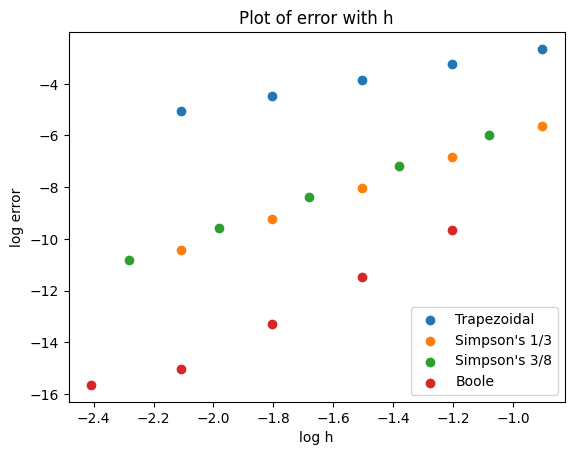

In [11]:
labels_int = ["Trapezoidal", "Simpson's 1/3", "Simpson's 3/8", "Boole"]
log_h = np.log10(hs_int)
log_err = np.log10(errors_int)

for i in range(len(methods)):
  plt.scatter(log_h[:, i], log_err[:, i], label = labels_int[i])

plt.xlabel("log h")
plt.ylabel("log error")
plt.title("Plot of error with h")
plt.legend()
plt.show()

**Part (c)**

Fit of log of error v/s log h

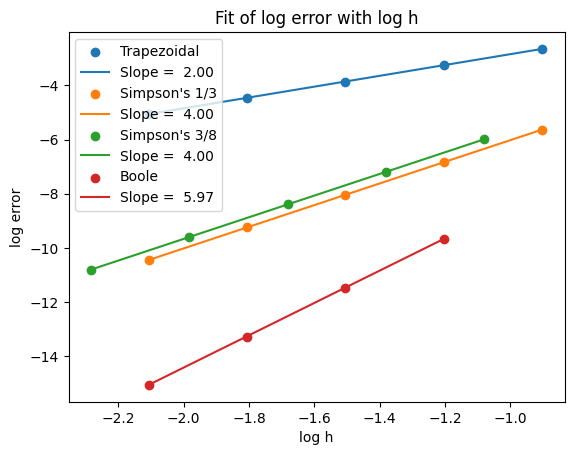

"\nTrapezoidal:\nSlope = 2 => log error = 2*log h => error proportional to h^2\n\nSimpson's 1/3 and Simpson's 3/8:\nSlope = 4 => log error = 4*log h => error proportional to h^4. Reasonably accurate.\n\nBoole's:\nSlope = 6 => log error = 6*log h => error proportional to h^6. Very accurate.\n"

In [12]:
for i in range(len(methods)):
  if i == 3:
    # Since Boole's method is very accurate, smaller h values produce tiny errors that are disturbed by machine precision. Hence we only take the first few values
    numdata = 4
  else:
    numdata = len(ms)

  popt, pcov = curve_fit(eqn_of_line, log_h[:numdata, i], log_err[:numdata, i])
  slope, intercept = popt
  plt.scatter(log_h[:numdata, i], log_err[:numdata, i], label = labels_int[i])
  plt.plot(log_h[:numdata, i], eqn_of_line(log_h[:numdata, i], slope, intercept), label = f"Slope = {slope: 0.2f}")

plt.xlabel("log h")
plt.ylabel("log error")
plt.title("Fit of log error with log h")
plt.legend()
plt.show()

'''
Trapezoidal:
Slope = 2 => log error = 2*log h => error proportional to h^2

Simpson's 1/3 and Simpson's 3/8:
Slope = 4 => log error = 4*log h => error proportional to h^4. Reasonably accurate.

Boole's:
Slope = 6 => log error = 6*log h => error proportional to h^6. Very accurate.
'''

## **Question 3:**

Use Simpson’s 3/8 method to integrate f(x) = x^−2/3(1 − x)^−1/3 from 0 to 1. The exact
integral is 2π/√3. Use variable substitutions to handle the singularities.

We use the variable substitution

`x = sin^2 t => dx = 2 cos(t) sin(t) dt`

The integrand becomes `2 cot^(1/3) t dt` from [0, π/2]. But it diverges at 0 as cot 0 tends to inf.

We make another substitution

`t = u^3 => dt = 6 * u^2 du`

The new integrand becomes `6 u^2 cot^1/3(u^3) du` from [0, π/2^1/3].

`At u -> 0 => cot^1/3 u^3 -> (1/u^3)^1/3 = 1/u`

`6 u^2/u = 6*u -> 0`

Hence, when u is close to 0, the integrand tends to 0. The integrand at the other limit is properly defined. Thus our transformed function is `g(u) = 6 u^2 cot^1/3(u^3)`

In [24]:
def g(u):
  u = np.array(u)   # To make it consistent with scalar inputs of u
  out = np.zeros_like(u)    # Output array
  mask = ~np.isclose(u, 0)    # True only for values where u is not close to 0

  # Calculation of g(x) only when values are not close to 0; rest of the time, out = 0
  out[mask] = 6 * (u[mask]**2) * 1/np.cbrt((np.sin(u[mask]**3))) * np.cbrt((np.cos(u[mask]**3)))

  return out

# Setting parameters
upper, lower = (math.pi/2)**(1/3), 0
exact = 2*np.pi/(3**0.5)
print(" m Calculated  Exact   Error")

# Checking error for different values of m
for m in ms:
  value, h = simpson_38(g, m, lower, upper)
  print("%2s  %0.5f  %0.5f  %0.5f" %(m, value, exact, abs(exact-value)))

 m Calculated  Exact   Error
 4  3.53204  3.62760  0.09555
 8  3.59015  3.62760  0.03745
16  3.61283  3.62760  0.01477
32  3.62176  3.62760  0.00584
64  3.62528  3.62760  0.00231
